In [43]:
%matplotlib inline  

import matplotlib as mpl  # 기본 설정 만지는 용도
import matplotlib.pyplot as plt  # 그래프 그리는 용도
import matplotlib.font_manager as fm  # 폰트 관련 용도
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore')
#plt.rc('font', family='NanumBarunGothic') 

from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [26]:
os.getcwd()

'/Users/hye0n0/UOS/경제분석캡스톤디자인/code'

In [44]:
student2019 = pd.read_csv('./KCYPS 2018 중1 코호트 제1~4차 조사 데이터/KCYPS2018m1Yw2.csv', encoding='cp949')
student2020 = pd.read_csv('./KCYPS 2018 중1 코호트 제1~4차 조사 데이터/KCYPS2018m1Yw3.csv', encoding='cp949')
student2021 = pd.read_csv('./KCYPS 2018 중1 코호트 제1~4차 조사 데이터/KCYPS2018m1Yw4.csv')

In [45]:
student2019.set_index(['HID', 'PID'], inplace=True)
student2020.set_index(['HID', 'PID'], inplace=True)
student2021.set_index(['HID', 'PID'], inplace=True)

In [46]:
parent2019 = pd.read_csv('./KCYPS 2018 중1 코호트 제1~4차 조사 데이터/KCYPS2018m1Pw2.csv', encoding='cp949')
parent2020 = pd.read_csv('./KCYPS 2018 중1 코호트 제1~4차 조사 데이터/KCYPS2018m1Pw3.csv', encoding='cp949')
parent2021 = pd.read_csv('./KCYPS 2018 중1 코호트 제1~4차 조사 데이터/KCYPS2018m1Pw4.csv')

In [47]:
parent2019.set_index(['HID', 'PID'], inplace=True)
parent2020.set_index(['HID', 'PID'], inplace=True)
parent2021.set_index(['HID', 'PID'], inplace=True)

In [32]:
student2019.head()

,,SCLIDw2,WEIGHTA1w2,WEIGHTA2w2,WEIGHTB1w2,WEIGHTB2w2,SURVEY1w2,SURVEY2w2,COHORTw2,ARA1Aw2,ARA2Aw2,...,YFAM2D03w2,YFAM2D04w2,YFAM2E01w2,YFAM2E02w2,YFAM2E03w2,YFAM2E04w2,YFAM2F01w2,YFAM2F02w2,YFAM2F03w2,YFAM2F04w2
HID,PID,,,,,,,,,,,,,,,,,,,,,
780,2,20409.0,214.693709,1.260687,215.721347,1.266721,1,1,m1,4.0,1.0,...,2.0,2.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0
1192,2,20912.0,87.627325,0.514550,87.931552,0.516336,1,1,m1,9.0,3.0,...,2.0,1.0,3.0,3.0,3.0,3.0,3.0,1.0,2.0,2.0
1193,2,40920.0,105.834960,0.621465,105.583650,0.619990,1,1,m1,9.0,3.0,...,2.0,2.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0
1285,2,20920.0,278.943119,1.637961,278.016670,1.632521,1,1,m1,9.0,2.0,...,2.0,2.0,1.0,1.0,3.0,2.0,3.0,3.0,1.0,2.0
1590,2,20936.0,83.644265,0.491161,83.125629,0.488116,1,1,m1,9.0,3.0,...,1.0,1.0,3.0,3.0,3.0,3.0,1.0,1.0,2.0,2.0


## 조사참여 여부

In [49]:
print(student2019['SURVEY1w2'].value_counts())
print(student2020['SURVEY1w3'].value_counts())
print(student2021['SURVEY1w4'].value_counts())

1    2438
2     152
Name: SURVEY1w2, dtype: int64
1    2384
2     206
Name: SURVEY1w3, dtype: int64
1    2265
2     325
Name: SURVEY1w4, dtype: int64


In [113]:
a=pd.merge(student2019, student2020, right_index=True, left_index=True)
b=pd.merge(a, student2021, right_index=True, left_index=True)
b

,,SCLIDw2,WEIGHTA1w2,WEIGHTA2w2,WEIGHTB1w2,WEIGHTB2w2,SURVEY1w2,SURVEY2w2,COHORTw2,ARA1Aw2,ARA2Aw2,...,YRME1A20w4,YRME1A21w4,YRME1A22w4,YRME1A23w4,YRME1A24w4,YRME1A25w4,YRME1A26w4,YRME1A27w4,YRME1A28w4,YRME1Ascw4
HID,PID,,,,,,,,,,,,,,,,,,,,,
780,2,20409.0,214.693709,1.260687,215.721347,1.266721,1,1,m1,4.0,1.0,...,,,,,,,,,,
1192,2,20912.0,87.627325,0.514550,87.931552,0.516336,1,1,m1,9.0,3.0,...,,,,,,,,,,
1193,2,40920.0,105.834960,0.621465,105.583650,0.619990,1,1,m1,9.0,3.0,...,3,1,4,3,1,4,3,3,4,21
1285,2,20920.0,278.943119,1.637961,278.016670,1.632521,1,1,m1,9.0,2.0,...,3,1,4,2,1,4,4,3,3,21
1590,2,20936.0,83.644265,0.491161,83.125629,0.488116,1,1,m1,9.0,3.0,...,2,2,2,2,3,3,3,3,3,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5157,1,21703.0,260.640000,1.530484,244.890755,1.438005,1,1,m1,17.0,2.0,...,,,,,,,,,,
5158,1,21703.0,260.640000,1.530484,226.303637,1.328861,1,1,m1,17.0,2.0,...,3,1,4,2,1,3,2,3,3,22
5159,1,21703.0,260.640000,1.530484,244.890755,1.438005,1,1,m1,17.0,2.0,...,1,1,1,2,1,3,3,3,3,21


In [116]:
b.value_counts()

Series([], dtype: int64)

In [123]:
b[['SURVEY1w2', 'SURVEY1w3', 'SURVEY1w4']].value_counts()

SURVEY1w2  SURVEY1w3  SURVEY1w4
1          1          1            2160
                      2             165
2          2          2              85
1          2          2              60
                      1              53
2          1          1              44
                      2              15
           2          1               8
dtype: int64

# 남녀

In [103]:
print(student2019['YGENDERw2'].value_counts())
print(student2020['YGENDERw3'].value_counts())
print(student2021['YGENDERw4'].value_counts())

1.0    1318
2.0    1120
Name: YGENDERw2, dtype: int64
1.0    1278
2.0    1106
Name: YGENDERw3, dtype: int64
1    1217
2    1048
      325
Name: YGENDERw4, dtype: int64


## 가해자 EDA

In [50]:
tviolence1=['YDLQ1A05w2', 'YDLQ1A06w2', 'YDLQ1A07w2', 'YDLQ1A08w2','YDLQ1A09w2', 'YDLQ1A10w2', 'YDLQ1A13w2']
cviolence1=['YDLQ2A03w2','YDLQ2A04w2', 'YDLQ2A05w2', 'YDLQ2A06w2', 'YDLQ2A07w2', 'YDLQ2A08w2', 'YDLQ2A09w2', 'YDLQ2A10w2', 'YDLQ2A12w2', 'YDLQ2A13w2','YDLQ2A14w2', 'YDLQ2A15w2']

tviolence2=['YDLQ1A05w3', 'YDLQ1A06w3', 'YDLQ1A07w3', 'YDLQ1A08w3','YDLQ1A09w3', 'YDLQ1A10w3', 'YDLQ1A13w3']
cviolence2=['YDLQ2A03w3','YDLQ2A04w3', 'YDLQ2A05w3', 'YDLQ2A06w3', 'YDLQ2A07w3', 'YDLQ2A08w3', 'YDLQ2A09w3', 'YDLQ2A10w3', 'YDLQ2A12w3', 'YDLQ2A13w3','YDLQ2A14w3', 'YDLQ2A15w3']

tviolence3=['YDLQ1A05w4', 'YDLQ1A06w4', 'YDLQ1A07w4', 'YDLQ1A08w4','YDLQ1A09w4', 'YDLQ1A10w4', 'YDLQ1A13w4']
cviolence3=['YDLQ2A03w4','YDLQ2A04w4', 'YDLQ2A05w4', 'YDLQ2A06w4', 'YDLQ2A07w4', 'YDLQ2A08w4', 'YDLQ2A09w4', 'YDLQ2A10w4', 'YDLQ2A12w4', 'YDLQ2A13w4','YDLQ2A14w4', 'YDLQ2A15w4']

In [51]:
for i in range(len(tviolence3)):
    student2021[tviolence3[i]] = pd.to_numeric(student2021[tviolence3[i]], errors='coerce')

for i in range(len(cviolence3)):
    student2021[cviolence3[i]] = pd.to_numeric(student2021[cviolence3[i]], errors='coerce')

In [52]:
def violence(data, tvio, cvio):
    df = data.copy()
    df['tv']=data[tvio].apply(lambda x: 1 if [2 or 3 or 4 or 5 or 6] in x.unique() else 0, axis=1)
    df['cv']=data[cvio].apply(lambda x: 1 if [2 or 3 or 4 or 5 or 6] in x.unique() else 0, axis=1)
    df['vio']=0
    df['vio'][(df['cv'] == 1) | (df['tv'] == 1)] = 1
    return df

In [53]:
v19=violence(student2019, tviolence1, cviolence1)
v20=violence(student2020, tviolence2, cviolence2)
v21=violence(student2021, tviolence3, cviolence3)

In [212]:
a19 = v19[['YDLQ1A05w2', 'YDLQ1A06w2', 'YDLQ1A07w2', 'YDLQ1A08w2','YDLQ1A09w2', 'YDLQ1A10w2', 'YDLQ1A13w2', 'YDLQ2A03w2','YDLQ2A04w2', 'YDLQ2A05w2', 'YDLQ2A06w2', 'YDLQ2A07w2', 'YDLQ2A08w2', 'YDLQ2A09w2', 'YDLQ2A10w2', 'YDLQ2A12w2', 'YDLQ2A13w2','YDLQ2A14w2', 'YDLQ2A15w2']]

In [213]:
(19/18)*(1 - a19.var().sum()/a19.apply(lambda x: sum(x), axis=1).var())

0.9729956322900362

In [214]:
a20 = v20[['YDLQ1A05w3', 'YDLQ1A06w3', 'YDLQ1A07w3', 'YDLQ1A08w3','YDLQ1A09w3', 'YDLQ1A10w3', 'YDLQ1A13w3', 'YDLQ2A03w3','YDLQ2A04w3', 'YDLQ2A05w3', 'YDLQ2A06w3', 'YDLQ2A07w3', 'YDLQ2A08w3', 'YDLQ2A09w3', 'YDLQ2A10w3', 'YDLQ2A12w3', 'YDLQ2A13w3','YDLQ2A14w3', 'YDLQ2A15w3']]

In [215]:
(19/18)*(1 - a20.var().sum()/a20.apply(lambda x: sum(x), axis=1).var())

0.9054944895683664

In [216]:
a21 = v21[['YDLQ1A05w4', 'YDLQ1A06w4', 'YDLQ1A07w4', 'YDLQ1A08w4','YDLQ1A09w4', 'YDLQ1A10w4', 'YDLQ1A13w4', 'YDLQ2A03w4','YDLQ2A04w4', 'YDLQ2A05w4', 'YDLQ2A06w4', 'YDLQ2A07w4', 'YDLQ2A08w4', 'YDLQ2A09w4', 'YDLQ2A10w4', 'YDLQ2A12w4', 'YDLQ2A13w4','YDLQ2A14w4', 'YDLQ2A15w4']]

In [217]:
(19/18)*(1 - a21.var().sum()/a21.apply(lambda x: sum(x), axis=1).var())

0.8189095018914746

In [54]:
v19.rename(columns={'tv':'tv19', 'cv':'cv19', 'vio':'vio19'}, inplace=True)
v20.rename(columns={'tv':'tv20', 'cv':'cv20', 'vio':'vio20'}, inplace=True)
v21.rename(columns={'tv':'tv21', 'cv':'cv21', 'vio':'vio21'}, inplace=True)

In [55]:
v19 = pd.merge(v19,parent2019, how='inner', right_index=True, left_index=True)
v20 = pd.merge(v20,parent2020, how='inner', right_index=True, left_index=True)
v21 = pd.merge(v21,parent2021, how='inner', right_index=True, left_index=True)

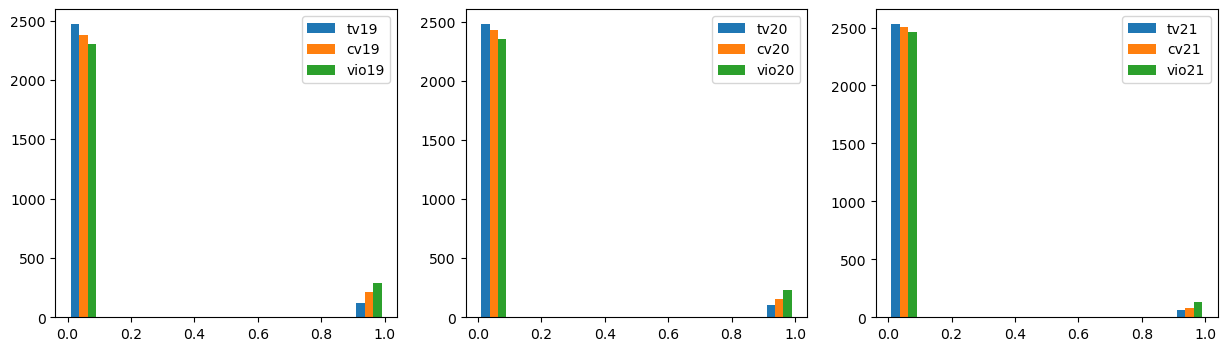

In [56]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(v19[['tv19', 'cv19', 'vio19']])
plt.legend(v19[['tv19', 'cv19', 'vio19']])

plt.subplot(1, 3, 2)
plt.hist(v20[['tv20', 'cv20', 'vio20']])
plt.legend(v20[['tv20', 'cv20', 'vio20']])

plt.subplot(1, 3, 3)
plt.hist(v21[['tv21', 'cv21', 'vio21']])
plt.legend(v21[['tv21', 'cv21', 'vio21']])

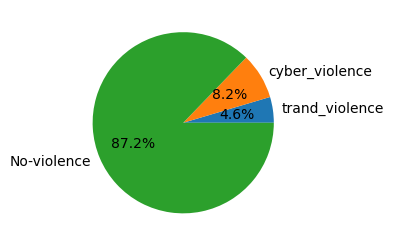

violence rate: 11.235521235521235 
----------------------------------
violence: 291 
---------------------------------------


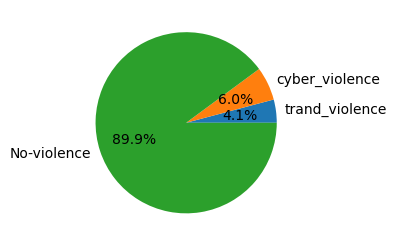

violence rate: 8.996138996138995 
----------------------------------
violence: 233 
---------------------------------------


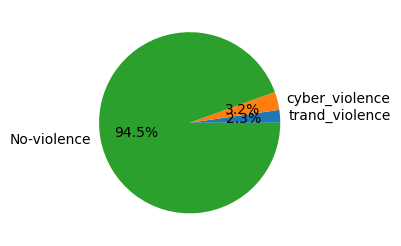

violence rate: 5.019305019305019 
----------------------------------
violence: 130 
---------------------------------------


In [57]:
j=1
for i in [v19, v20, v21]:
    plt.figure(figsize=(10, 10))
    num = ['19', '20', '21']
    patiovio=sum(i[f'vio{num[j-1]}'] == 1)/len(i) * 100
    patiotv=sum(i[f'tv{num[j-1]}'] == 1)/len(i) * 100
    patiosv=sum(i[f'cv{num[j-1]}'] == 1)/len(i) * 100
    gen = 100 - patiosv - patiotv
    
    ratio = [patiotv, patiosv, gen]
    labels = ['trand_violence', 'cyber_violence', 'No-violence']
    plt.subplot(3, 1, j)
    plt.pie(ratio, labels=labels, autopct='%.1f%%')
    plt.show()
    
    print('violence rate: {}'.format(patiovio), '\n----------------------------------')
    print('violence: {}'.format(sum(i[f'vio{num[j-1]}'] == 1)), '\n---------------------------------------')
    j += 1

## 가해자 컬럼 생성

In [58]:
v1920=pd.merge(v19, v20, how='inner', right_index=True, left_index=True)
v192021=pd.merge(v1920, v21,  how='inner', right_index=True, left_index=True)

# 한 번이라도 가해했다면, 1
v192021.vio_ary = v192021[['vio19', 'vio20', 'vio21']].apply(lambda x: sum(x) >= 1, axis=1).astype(int)
v192021.vio_ary 

HID   PID
780   2      1
1192  2      0
1193  2      0
1285  2      1
1590  2      0
            ..
5157  1      1
5158  1      1
5159  1      1
5160  1      0
5161  1      0
Length: 2590, dtype: int64

In [59]:
print(sum(v192021.vio_ary==1) )

522


In [60]:
def col_make(col_name):
    total_col = []
    for year in range(2, 5):
        year = str(year)
        col = []
        for i in col_name:
            i = i[:-1]+year
            col.append(i)
        total_col.append(col)
    return total_col[0], total_col[1], total_col[2] 


In [61]:
def convert_numeric(col):
    for i in range(len(col)):
        v21[col[i]] = pd.to_numeric(v21[col[i]], errors='coerce')
    return v21[col]

## 스마트폰 의존도

In [152]:
smart = ['YMDA1C01w2', 'YMDA1C02w2','YMDA1C03w2', 'YMDA1C04w2', 'YMDA1C06w2', 'YMDA1C07w2','YMDA1C08w2', 'YMDA1C09w2',  'YMDA1C11w2', 'YMDA1C12w2','YMDA1C13w2', 'YMDA1C14w2'] 
inv_smart = ['YMDA1C05w2', 'YMDA1C10w2', 'YMDA1C15w2']

smart19, smart20, smart21 = col_make(smart)
invsmart19, invsmart20, invsmart21 = col_make(inv_smart)

smart_col19 = v19[smart19]
invsmart_col19 = v19[invsmart19].apply(lambda x: -(x-5), axis=1)
smartphone_ary19 = pd.merge(smart_col19, invsmart_col19, left_index=True, right_index=True)
smartphone_ary19 = smartphone_ary19.apply(lambda x: round(np.mean(x), 3), axis=1)

smart_col20 = v20[smart20]
invsmart_col20 = v20[invsmart20].apply(lambda x: -(x-5), axis=1)
smartphone_ary20 = pd.merge(smart_col20, invsmart_col20, left_index=True, right_index=True)
smartphone_ary20 = smartphone_ary20.apply(lambda x: round(np.mean(x), 3), axis=1)

smart_col21 = convert_numeric(smart21)
invsmart_col21 = convert_numeric(invsmart21).apply(lambda x: -(x-5), axis=1)
smartphone_ary21 = pd.merge(smart_col21, invsmart_col21, left_index=True, right_index=True)
smartphone_ary21 = smartphone_ary21.apply(lambda x: round(np.mean(x), 3), axis=1)


print(smartphone_ary19.head(5),smartphone_ary20.head(5), smartphone_ary21.head(5))

HID   PID
780   2      2.200
1192  2      2.800
1193  2      2.333
1285  2      1.800
1590  2      1.867
dtype: float64 HID   PID
780   2      2.267
1192  2      2.533
1193  2      2.400
1285  2      1.867
1590  2      1.267
dtype: float64 HID   PID
780   2        NaN
1192  2        NaN
1193  2      2.200
1285  2      2.000
1590  2      1.933
dtype: float64


In [153]:
smart = ['YMDA1C01w2', 'YMDA1C02w2','YMDA1C03w2', 'YMDA1C04w2', 'YMDA1C06w2', 'YMDA1C07w2','YMDA1C08w2', 'YMDA1C09w2',  'YMDA1C11w2', 'YMDA1C12w2','YMDA1C13w2', 'YMDA1C14w2'] 
inv_smart = ['YMDA1C05w2', 'YMDA1C10w2', 'YMDA1C15w2']
(len(smart), len(inv_smart))

(12, 3)

In [156]:
(15/14)*(1 - smart_col19.var().sum()/smart_col19.apply(lambda x: sum(x), axis=1).var())

0.8684404118963279

In [157]:
(15/14)*(1 - smart_col20.var().sum()/smart_col20.apply(lambda x: sum(x), axis=1).var())

0.8853875684814703

In [158]:
(15/14)*(1 - smart_col21.var().sum()/smart_col21.apply(lambda x: sum(x), axis=1).var())

0.8772654601338646

## 학업열의, 학업무기력

In [160]:
studypos=['YINT2A02w2', 'YINT2A03w2', 'YINT2A04w2', 'YINT2A10w2', 'YINT2A12w2', 'YINT2A13w2', 'YINT2A15w2']
studyneg=['YINT2B02w2','YINT2B03w2', 'YINT2B05w2',  'YINT2B08w2', 'YINT2B10w2','YINT2B11w2', 'YINT2B12w2', 'YINT2B13w2', 'YINT2B15w2']

studypos19, studypos20, studypos21 = col_make(studypos)
studyneg19, studyneg20, studyneg21 = col_make(studyneg)

studypos_col19 = v19[studypos19]
studyneg_col19 = v19[studyneg19]
studypos_ary19 = studypos_col19.apply(lambda x: round(np.mean(x), 3), axis=1)
studyneg_ary19 = studyneg_col19.apply(lambda x: round(np.mean(x), 3), axis=1)

studypos_col20 = v20[studypos20]
studyneg_col20 = v20[studyneg20]
studypos_ary20 = studypos_col20.apply(lambda x: round(np.mean(x), 3), axis=1)
studyneg_ary20 = studyneg_col20.apply(lambda x: round(np.mean(x), 3), axis=1)

studypos_col21 = convert_numeric(studypos21)
studyneg_col21 = convert_numeric(studyneg21)
studypos_ary21 = studypos_col21.apply(lambda x: round(np.mean(x), 3), axis=1)
studyneg_ary21 = studyneg_col21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(studypos_ary19.head(5),studypos_ary20.head(5), studypos_ary21.head(5))

HID   PID
780   2      3.000
1192  2      3.143
1193  2      2.714
1285  2      2.000
1590  2      2.429
dtype: float64 HID   PID
780   2      2.571
1192  2      2.571
1193  2      2.714
1285  2      2.143
1590  2      3.286
dtype: float64 HID   PID
780   2        NaN
1192  2        NaN
1193  2      2.571
1285  2      2.429
1590  2      2.429
dtype: float64


In [161]:
(7/6)*(1 - studypos_col19.var().sum()/studypos_col19.apply(lambda x: sum(x), axis=1).var())

0.8273976466540527

In [162]:
(7/6)*(1 - studypos_col20.var().sum()/studypos_col20.apply(lambda x: sum(x), axis=1).var())

0.8361735772592203

In [163]:
(7/6)*(1 - studypos_col21.var().sum()/studypos_col21.apply(lambda x: sum(x), axis=1).var())

0.8171376920599314

## 삶의 만족도

In [165]:
lifesatisfy = ['YPSY1A01w2', 'YPSY1A02w2', 'YPSY1A03w2', 'YPSY1A04w2', 'YPSY1A05w2']
lifesatisfy19, lifesatisfy20, lifesatisfy21 = col_make(lifesatisfy)

lifesatis_col19 = v19[lifesatisfy19]
lifesatis_ary19 = lifesatis_col19.apply(lambda x: round(np.mean(x), 3), axis=1)

lifesatis_col20 = v20[lifesatisfy20]
lifesatis_ary20 = lifesatis_col20.apply(lambda x: round(np.mean(x), 3), axis=1)

lifesatis_col21 = convert_numeric(lifesatisfy21)
lifesatis_ary21 = lifesatis_col21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(lifesatis_ary19.head(5),lifesatis_ary20.head(5), lifesatis_ary21.head(5))

HID   PID
780   2      2.0
1192  2      2.6
1193  2      3.0
1285  2      2.0
1590  2      2.0
dtype: float64 HID   PID
780   2      1.8
1192  2      3.2
1193  2      3.8
1285  2      2.2
1590  2      2.8
dtype: float64 HID   PID
780   2      NaN
1192  2      NaN
1193  2      3.2
1285  2      2.4
1590  2      2.8
dtype: float64


In [166]:
(5/4)*(1 - lifesatis_col19.var().sum()/lifesatis_col19.apply(lambda x: sum(x), axis=1).var())

0.8162226736855943

In [168]:
(5/4)*(1 - lifesatis_col20.var().sum()/lifesatis_col20.apply(lambda x: sum(x), axis=1).var())

0.8229534873756515

In [169]:
(5/4)*(1 - lifesatis_col21.var().sum()/lifesatis_col21.apply(lambda x: sum(x), axis=1).var())

0.8105456267665205

## 행복감

In [50]:
happy = ['YPSY2A01w2', 'YPSY2A02w2', 'YPSY2A03w2']
unhappy = ['YPSY2A04w2']
happy19, happy20, happy21 = col_make(happy)
unhappy19, unhappy20, unhappy21 = col_make(unhappy)

happy_col19 = v19[happy19]
unhappy_col19 = v19[unhappy19].apply(lambda x: -(x-5), axis=1)
happy_ary19 = pd.merge(happy_col19, unhappy_col19, left_index=True, right_index=True)
happy_ary19 = happy_ary19.apply(lambda x: round(np.mean(x), 3), axis=1)

happy_col20 = v20[happy20]
unhappy_col20 = v20[unhappy20].apply(lambda x: -(x-5), axis=1)
happy_ary20 = pd.merge(happy_col20, unhappy_col20, left_index=True, right_index=True)
happy_ary20 = happy_ary20.apply(lambda x: round(np.mean(x), 3), axis=1)

happy_col21 = convert_numeric(happy21)
unhappy_col21 = convert_numeric(unhappy21).apply(lambda x: -(x-5), axis=1)
happy_ary21 = pd.merge(happy_col21, unhappy_col21, left_index=True, right_index=True)
happy_ary21 = happy_ary21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(happy_ary19.head(5),happy_ary20.head(5), happy_ary21.head(5))

HID   PID
780   2      2.25
1192  2      3.00
1193  2      3.75
1285  2      3.25
1590  2      3.25
dtype: float64 HID   PID
780   2      3.00
1192  2      3.00
1193  2      2.75
1285  2      3.50
1590  2      3.25
dtype: float64 HID   PID
780   2       NaN
1192  2       NaN
1193  2      3.50
1285  2      2.75
1590  2      2.50
dtype: float64


## 자아존중감

In [51]:
selfp = ['YPSY3A01w2', 'YPSY3A03w2', 'YPSY3A04w2', 'YPSY3A07w2', 'YPSY3A10w2']
selfn = ['YPSY3A02w2', 'YPSY3A05w2', 'YPSY3A06w2', 'YPSY3A09w2']
selfpos19, selfpos20, selfpos21 = col_make(selfp)
selfneg19, selfneg20, selfneg21 = col_make(selfn)

selfpos_col19 = v19[selfpos19]
selfneg_col19 = v19[selfneg19].apply(lambda x: -(x-5), axis=1)
selfpos_ary19 = pd.merge(selfpos_col19, selfneg_col19, left_index=True, right_index=True)
selfpos_ary19 = selfpos_ary19.apply(lambda x: round(np.mean(x), 3), axis=1)

selfpos_col20 = v20[selfpos20]
selfneg_col20 = v20[selfneg20].apply(lambda x: -(x-5), axis=1)
selfpos_ary20 = pd.merge(selfpos_col20, selfneg_col20, left_index=True, right_index=True)
selfpos_ary20 = selfpos_ary20.apply(lambda x: round(np.mean(x), 3), axis=1)

selfpos_col21 = convert_numeric(selfpos21)
selfneg_col21 = convert_numeric(selfneg21).apply(lambda x: -(x-5), axis=1)
selfpos_ary21 = pd.merge(selfpos_col21, selfneg_col21, left_index=True, right_index=True)
selfpos_ary21 = selfpos_ary21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(selfpos_ary19.head(5),selfpos_ary20.head(5), selfpos_ary21.head(5))

HID   PID
780   2      2.556
1192  2      3.000
1193  2      4.000
1285  2      3.111
1590  2      3.444
dtype: float64 HID   PID
780   2      2.778
1192  2      2.556
1193  2      3.556
1285  2      3.222
1590  2      3.444
dtype: float64 HID   PID
780   2      NaN
1192  2      NaN
1193  2      4.0
1285  2      3.0
1590  2      3.0
dtype: float64


## 공격성

In [171]:
angry = ['YPSY4B01w2', 'YPSY4B02w2', 'YPSY4B03w2', 'YPSY4B04w2', 'YPSY4B05w2']
angry19, angry20, angry21 = col_make(angry)

angry_col19 = v19[angry19]
angry_ary19 = angry_col19.apply(lambda x: round(np.mean(x), 3), axis=1)

angry_col20 = v20[angry20]
angry_ary20 = angry_col20.apply(lambda x: round(np.mean(x), 3), axis=1)

angry_col21 = convert_numeric(angry21)
angry_ary21 = angry_col21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(angry_ary19.head(5),angry_ary20.head(5), angry_ary21.head(5))

HID   PID
780   2      3.0
1192  2      2.0
1193  2      2.0
1285  2      2.0
1590  2      1.8
dtype: float64 HID   PID
780   2      3.4
1192  2      3.2
1193  2      2.2
1285  2      2.4
1590  2      1.2
dtype: float64 HID   PID
780   2      NaN
1192  2      NaN
1193  2      2.4
1285  2      2.4
1590  2      2.4
dtype: float64


In [172]:
(5/4)*(1 - angry_col19.var().sum()/angry_col19.apply(lambda x: sum(x), axis=1).var())

0.8564735315040772

In [173]:
(5/4)*(1 - angry_col20.var().sum()/angry_col20.apply(lambda x: sum(x), axis=1).var())

0.8647674868552779

In [174]:
(5/4)*(1 - angry_col21.var().sum()/angry_col21.apply(lambda x: sum(x), axis=1).var())

0.8529969494116341

## 우울

In [176]:
dump = ['YPSY4B06w2', 'YPSY4E02w2', 'YPSY4E04w2', 'YPSY4E05w2', 'YPSY4E06w2', 'YPSY4E09w2', 'YPSY4E10w2']

dump19, dump20, dump21 = col_make(dump)

dump_col19 = v19[dump19]
dump_ary19 = dump_col19.apply(lambda x: round(np.mean(x), 3), axis=1)

dump_col20 = v20[dump20]
dump_ary20 = dump_col20.apply(lambda x: round(np.mean(x), 3), axis=1)

dump_col21 = convert_numeric(dump21)
dump_ary21 = dump_col21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(dump_ary19.head(5),dump_ary20.head(5), dump_ary21.head(5))

HID   PID
780   2      2.857
1192  2      1.714
1193  2      1.571
1285  2      1.857
1590  2      1.714
dtype: float64 HID   PID
780   2      2.143
1192  2      2.857
1193  2      2.143
1285  2      1.714
1590  2      1.286
dtype: float64 HID   PID
780   2        NaN
1192  2        NaN
1193  2      2.143
1285  2      1.286
1590  2      1.857
dtype: float64


In [179]:
(7/6)*(1 - dump_col19.var().sum()/dump_col19.apply(lambda x: sum(x), axis=1).var())

0.8828317154344647

In [177]:
(7/6)*(1 - dump_col20.var().sum()/dump_col20.apply(lambda x: sum(x), axis=1).var())

0.8800778246969938

In [178]:
(7/6)*(1 - dump_col21.var().sum()/dump_col21.apply(lambda x: sum(x), axis=1).var())

0.8695603922935092

## 협동심

In [181]:
group = ['YPSY5A01w2', 'YPSY5A02w2','YPSY5A03w2', 'YPSY5A05w2','YPSY5A06w2', 'YPSY5A07w2','YPSY5A08w2', 'YPSY5A09w2','YPSY5A10w2', 'YPSY5A11w2','YPSY5A12w2', 'YPSY5A13w2','YPSY5A14w2']

group19, group20, group21 = col_make(group)

group_col19 = v19[group19]
group_ary19 = group_col19.apply(lambda x: round(np.mean(x), 3), axis=1)

group_col20 = v20[group20]
group_ary20 = group_col20.apply(lambda x: round(np.mean(x), 3), axis=1)

group_col21 = convert_numeric(group21)
group_ary21 = group_col21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(group_ary19.head(5),group_ary20.head(5), group_ary21.head(5))

HID   PID
780   2      4.000
1192  2      3.308
1193  2      4.000
1285  2      2.538
1590  2      2.846
dtype: float64 HID   PID
780   2      3.000
1192  2      2.846
1193  2      3.231
1285  2      2.538
1590  2      3.154
dtype: float64 HID   PID
780   2        NaN
1192  2        NaN
1193  2      3.000
1285  2      2.538
1590  2      3.462
dtype: float64


In [182]:
(13/12)*(1 - group_col19.var().sum()/group_col19.apply(lambda x: sum(x), axis=1).var())

0.9207070885605124

In [183]:
(13/12)*(1 - group_col20.var().sum()/group_col20.apply(lambda x: sum(x), axis=1).var())

0.9133423929209671

In [184]:
(13/12)*(1 - group_col21.var().sum()/group_col21.apply(lambda x: sum(x), axis=1).var())

0.9205016734085045

## 그릿

In [55]:
grit = ['YPSY7A02w2','YPSY7A04w2','YPSY7A07w2','YPSY7A08w2']
ungrit = ['YPSY7A01w2','YPSY7A03w2','YPSY7A05w2','YPSY7A06w2']

grit19, grit20, grit21 = col_make(grit)
ungrit19, ungrit20, ungrit21 = col_make(ungrit)

grit_col19 = v19[grit19]
ungrit_col19 = v19[ungrit19].apply(lambda x: -(x-5), axis=1)
grit_ary19 = pd.merge(grit_col19, ungrit_col19, left_index=True, right_index=True)
grit_ary19 = grit_ary19.apply(lambda x: round(np.mean(x), 3), axis=1)

grit_col20 = v20[grit20]
ungrit_col20 = v20[ungrit20].apply(lambda x: -(x-5), axis=1)
grit_ary20 = pd.merge(grit_col20, ungrit_col20, left_index=True, right_index=True)
grit_ary20 = grit_ary20.apply(lambda x: round(np.mean(x), 3), axis=1)

grit_col21 = convert_numeric(grit21)
ungrit_col21 = convert_numeric(ungrit21).apply(lambda x: -(x-5), axis=1)
grit_ary21 = pd.merge(grit_col21, ungrit_col21, left_index=True, right_index=True)
grit_ary21 = grit_ary21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(grit_ary19.head(5),grit_ary20.head(5), grit_ary21.head(5))

HID   PID
780   2      2.500
1192  2      3.000
1193  2      2.750
1285  2      2.625
1590  2      3.125
dtype: float64 HID   PID
780   2      2.500
1192  2      2.375
1193  2      2.250
1285  2      2.500
1590  2      3.000
dtype: float64 HID   PID
780   2       NaN
1192  2       NaN
1193  2      2.50
1285  2      2.25
1590  2      2.25
dtype: float64


## 주의산만

In [62]:
distraction = ['YPSY4A01w2','YPSY4A02w2','YPSY4A03w2','YPSY4A05w2','YPSY4A06w2']

distraction19, distraction20, distraction21 = col_make(distraction)

distraction_col19 = v19[distraction19]
distraction_ary19 = distraction_col19.apply(lambda x: round(np.mean(x), 3), axis=1)

distraction_col20 = v20[distraction20]
distraction_ary20 = distraction_col20.apply(lambda x: round(np.mean(x), 3), axis=1)

distraction_col21 = convert_numeric(distraction21)
distraction_ary21 = distraction_col21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(distraction_ary19.head(5),distraction_ary20.head(5), distraction_ary21.head(5))

HID   PID
780   2      2.4
1192  2      2.2
1193  2      2.2
1285  2      2.4
1590  2      2.0
dtype: float64 HID   PID
780   2      3.2
1192  2      2.6
1193  2      2.6
1285  2      2.4
1590  2      1.4
dtype: float64 HID   PID
780   2      NaN
1192  2      NaN
1193  2      2.8
1285  2      2.6
1590  2      2.8
dtype: float64


## 부모와 보내는 시간

In [57]:
timewithparent = ['YTIM1D01w2', 'YTIM1D02w2']

timewithparent19, timewithparent20, timewithparent21 = col_make(timewithparent)

timewithparent_col19 = v19[timewithparent19]
timewithparent_ary19 = timewithparent_col19.apply(lambda x: sum(x), axis=1)

timewithparent_col20 = v20[timewithparent20]
timewithparent_ary20 = timewithparent_col20.apply(lambda x: sum(x), axis=1)

timewithparent_col21 = convert_numeric(timewithparent21)
timewithparent_ary21 = timewithparent_col21.apply(lambda x: sum(x), axis=1)

print(timewithparent_ary19.head(5),timewithparent_ary20.head(5), timewithparent_ary21.head(5))

HID   PID
780   2      11.0
1192  2       7.0
1193  2       8.0
1285  2       7.0
1590  2       8.0
dtype: float64 HID   PID
780   2       9.0
1192  2       4.0
1193  2      12.0
1285  2       7.0
1590  2      14.0
dtype: float64 HID   PID
780   2       NaN
1192  2       NaN
1193  2      12.0
1285  2       6.0
1590  2       8.0
dtype: float64


## 부모 애정

In [125]:
parentlove = ['YFAM2A01w2', 'YFAM2A02w2', 'YFAM2A03w2', 'YFAM2A04w2', 'YFAM2C01w2', 'YFAM2C02w2', 'YFAM2C04w2']

parentlove19, parentlove20, parentlove21 = col_make(parentlove)

parentlove_col19 = v19[parentlove19]
parentlove_ary19 = parentlove_col19.apply(lambda x: round(np.mean(x), 3), axis=1)

parentlove_col20 = v20[parentlove20]
parentlove_ary20 = parentlove_col20.apply(lambda x: round(np.mean(x), 3), axis=1)

parentlove_col21 = convert_numeric(parentlove21)
parentlove_ary21 = parentlove_col21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(parentlove_ary19.head(5),parentlove_ary20.head(5), parentlove_ary21.head(5))

HID   PID
780   2      3.000
1192  2      3.429
1193  2      3.000
1285  2      2.857
1590  2      3.286
dtype: float64 HID   PID
780   2      2.857
1192  2      3.286
1193  2      3.857
1285  2      3.000
1590  2      3.429
dtype: float64 HID   PID
780   2        NaN
1192  2        NaN
1193  2      3.429
1285  2      2.857
1590  2      3.000
dtype: float64


In [134]:
(7/6)*(1 - parentlove_col19.var().sum()/parentlove_col19.apply(lambda x: sum(x), axis=1).var())

0.9052276266978795

In [137]:
(7/6)*(1 - parentlove_col20.var().sum()/parentlove_col20.apply(lambda x: sum(x), axis=1).var())

0.8992798529941676

In [136]:
(7/6)*(1 - parentlove_col21.var().sum()/parentlove_col21.apply(lambda x: sum(x), axis=1).var())

0.9051605272530635

## 부모 강요

In [147]:
parentorder = ['YFAM2D01w2','YFAM2D02w2', 'YFAM2D03w2','YFAM2D04w2','YFAM2F04w2']

parentorder19, parentorder20, parentorder21 = col_make(parentorder)

parentorder_col19 = v19[parentorder19]
parentorder_ary19 = parentorder_col19.apply(lambda x: round(np.mean(x), 3), axis=1)

parentorder_col20 = v20[parentorder20]
parentorder_ary20 = parentorder_col20.apply(lambda x: round(np.mean(x), 3), axis=1)

parentorder_col21 = convert_numeric(parentorder21)
parentorder_ary21 = parentorder_col21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(parentorder_ary19.head(5),parentorder_ary20.head(5), parentorder_ary21.head(5))

HID   PID
780   2      2.8
1192  2      2.2
1193  2      2.2
1285  2      2.0
1590  2      1.6
dtype: float64 HID   PID
780   2      2.6
1192  2      3.2
1193  2      2.6
1285  2      1.8
1590  2      1.2
dtype: float64 HID   PID
780   2      NaN
1192  2      NaN
1193  2      2.2
1285  2      1.2
1590  2      2.0
dtype: float64


In [148]:
(5/4)*(1 - parentorder_col19.var().sum()/parentorder_col19.apply(lambda x: sum(x), axis=1).var())

0.7919522233527179

In [149]:
(5/4)*(1 - parentorder_col20.var().sum()/parentorder_col20.apply(lambda x: sum(x), axis=1).var())

0.8167769391609956

In [150]:
(5/4)*(1 - parentorder_col21.var().sum()/parentorder_col21.apply(lambda x: sum(x), axis=1).var())

0.7673340422138225

## 비행

In [190]:
bully = ['YDLQ1A01w2','YDLQ1A02w2', 'YDLQ1A03w2','YDLQ1A04w2','YDLQ1A14w2']

bully19, bully20, bully21 = col_make(bully)

bully_col19 = v19[bully19]
bully_ary19 = bully_col19.apply(lambda x: round(np.mean(x), 3), axis=1)

bully_col20 = v20[bully20]
bully_ary20 = bully_col20.apply(lambda x: round(np.mean(x), 3), axis=1)

bully_col21 = convert_numeric(bully21)
bully_ary21 = bully_col21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(bully_ary19.head(5),bully_ary20.head(5), bully_ary21.head(5))

HID   PID
780   2      1.0
1192  2      1.0
1193  2      1.2
1285  2      1.0
1590  2      1.0
dtype: float64 HID   PID
780   2      1.0
1192  2      1.0
1193  2      1.0
1285  2      1.0
1590  2      1.0
dtype: float64 HID   PID
780   2      NaN
1192  2      NaN
1193  2      1.0
1285  2      1.0
1590  2      1.0
dtype: float64


In [186]:
(5/4)*(1 - bully_col19.var().sum()/bully_col19.apply(lambda x: sum(x), axis=1).var())

0.8955306386101163

In [187]:
(5/4)*(1 - bully_col20.var().sum()/bully_col20.apply(lambda x: sum(x), axis=1).var())

0.7059934288608058

In [197]:
(1-bully_col21.var().sum())*5 / bully_col21.apply(lambda x: sum(x), axis=1).var()*4

6.318266541297582

## 보호자 관계

In [61]:
parentrelation19 = 'PFAM2A01w2'
parentrelation20 = 'PFAM2A01w3'
parentrelation21 = 'PFAM2A01w4'

parentrelation_ary19 = v19[parentrelation19]

parentrelation_ary20 = v20[parentrelation20]

parentrelation_ary21 = pd.to_numeric(v21[parentrelation21], errors='coerce')

print(parentrelation_ary19.head(5),parentrelation_ary20.head(5), parentrelation_ary21.head(5))

HID   PID
780   2      1.0
1192  2      1.0
1193  2      1.0
1285  2      1.0
1590  2      1.0
Name: PFAM2A01w2, dtype: float64 HID   PID
780   2      1.0
1192  2      1.0
1193  2      1.0
1285  2      1.0
1590  2      1.0
Name: PFAM2A01w3, dtype: float64 HID   PID
780   2      NaN
1192  2      NaN
1193  2      1.0
1285  2      1.0
1590  2      1.0
Name: PFAM2A01w4, dtype: float64


In [62]:
def parent_class(x):
    y = 0
    if (x == 1) or (x == 2):
        y = 1
    elif (x == 3) or (x == 4):
        y = 2
    elif x==5:
        y = 3
    else:
        y = 4
    return y

In [63]:
relaiton_class_ary19 = parentrelation_ary19.apply(lambda x: parent_class(x))
relaiton_class_ary20 = parentrelation_ary20.apply(lambda x: parent_class(x))
relaiton_class_ary21 = parentrelation_ary21.apply(lambda x: parent_class(x))
print(relaiton_class_ary19.head(5),relaiton_class_ary20.head(5), relaiton_class_ary21.head(5))

HID   PID
780   2      1
1192  2      1
1193  2      1
1285  2      1
1590  2      1
Name: PFAM2A01w2, dtype: int64 HID   PID
780   2      1
1192  2      1
1193  2      1
1285  2      1
1590  2      1
Name: PFAM2A01w3, dtype: int64 HID   PID
780   2      4
1192  2      4
1193  2      1
1285  2      1
1590  2      1
Name: PFAM2A01w4, dtype: int64


## 부모 소득

In [64]:
parentincoem = 'PINCOMEw2'

parentincome19 = 'PINCOMEw2'
parentincome20 = 'PINCOMEw3'
parentincome21 = 'PINCOMEw4'

parentincome_ary19 = v19[parentincome19]

parentincome_ary20 = v20[parentincome20]

parentincome_ary21 = pd.to_numeric(v21[parentincome21], errors='coerce')

print(parentincome_ary19.head(5),parentincome_ary20.head(5), parentincome_ary21.head(5))

HID   PID
780   2       5.0
1192  2       6.0
1193  2      10.0
1285  2       6.0
1590  2       3.0
Name: PINCOMEw2, dtype: float64 HID   PID
780   2       5.0
1192  2       7.0
1193  2      10.0
1285  2       6.0
1590  2       3.0
Name: PINCOMEw3, dtype: float64 HID   PID
780   2       NaN
1192  2       NaN
1193  2      10.0
1285  2       6.0
1590  2       4.0
Name: PINCOMEw4, dtype: float64


In [65]:
parentincome_ary19[parentincome_ary19 == 9.999e+03] = np.nan
parentincome_ary20[parentincome_ary20 == 9.999e+03] = np.nan
parentincome_ary21[parentincome_ary21 == 9.999e+03] = np.nan

In [66]:
def pinc(x):
    y = 0
    if (x == 1) or (x == 2):
        y = 1
    elif (x == 11) or (x == 12):
        y = 10
    else:
        y = x - 1
    return y

In [67]:
parentincome_ary19 = parentincome_ary19.apply(lambda x: pinc(x))
parentincome_ary20 = parentincome_ary20.apply(lambda x: pinc(x))
parentincome_ary21 = parentincome_ary21.apply(lambda x: pinc(x))

print(parentincome_ary19.head(5),parentincome_ary20.head(5), parentincome_ary21.head(5))

HID   PID
780   2      4.0
1192  2      5.0
1193  2      9.0
1285  2      5.0
1590  2      2.0
Name: PINCOMEw2, dtype: float64 HID   PID
780   2      4.0
1192  2      6.0
1193  2      9.0
1285  2      5.0
1590  2      2.0
Name: PINCOMEw3, dtype: float64 HID   PID
780   2      NaN
1192  2      NaN
1193  2      9.0
1285  2      5.0
1590  2      3.0
Name: PINCOMEw4, dtype: float64


## 보호자 자아존중감

In [83]:
p_selfp = ['PPSY3A01w2', 'PPSY3A03w2', 'PPSY3A04w2', 'PPSY3A07w2', 'PPSY3A10w2']
p_selfn = ['PPSY3A02w2', 'PPSY3A05w2', 'PPSY3A06w2', 'PPSY3A09w2']
p_selfpos19, p_selfpos20, p_selfpos21 = col_make(p_selfp)
p_selfneg19, p_selfneg20, p_selfneg21 = col_make(p_selfn)

p_selfpos_col19 = v19[p_selfpos19]
p_selfneg_col19 = v19[p_selfneg19].apply(lambda x: -(x-5), axis=1)
p_selfpos_ary19 = pd.merge(p_selfpos_col19, p_selfneg_col19, left_index=True, right_index=True)
p_selfpos_ary19 = p_selfpos_ary19.apply(lambda x: round(np.mean(x), 3), axis=1)

p_selfpos_col20 = v20[p_selfpos20]
p_selfneg_col20 = v20[p_selfneg20].apply(lambda x: -(x-5), axis=1)
p_selfpos_ary20 = pd.merge(p_selfpos_col20, p_selfneg_col20, left_index=True, right_index=True)
p_selfpos_ary20 = p_selfpos_ary20.apply(lambda x: round(np.mean(x), 3), axis=1)

p_selfpos_col21 = convert_numeric(p_selfpos21)
p_selfneg_col21 = convert_numeric(p_selfneg21).apply(lambda x: -(x-5), axis=1)
p_selfpos_ary21 = pd.merge(p_selfpos_col21, p_selfneg_col21, left_index=True, right_index=True)
p_selfpos_ary21 = p_selfpos_ary21.apply(lambda x: round(np.mean(x), 3), axis=1)

print(p_selfpos_ary19.head(5),p_selfpos_ary20.head(5), p_selfpos_ary21.head(5))

HID   PID
780   2      1.778
1192  2      3.000
1193  2      3.444
1285  2      3.556
1590  2      2.889
dtype: float64 HID   PID
780   2      1.667
1192  2      2.444
1193  2      3.444
1285  2      3.333
1590  2      3.222
dtype: float64 HID   PID
780   2        NaN
1192  2        NaN
1193  2      3.444
1285  2      3.000
1590  2      3.000
dtype: float64


## 최종 데이터 생성

In [87]:
variables = [smartphone_ary19, studyneg_ary19, studypos_ary19,
            lifesatis_ary19, happy_ary19, selfpos_ary19,
            angry_ary19, dump_ary19, group_ary19, grit_ary19, distraction_ary19,
            timewithparent_ary19, parentlove_ary19, parentorder_ary19,
            relaiton_class_ary19, parentincome_ary19, bully_ary19, p_selfpos_ary19]
data19 = pd.DataFrame(smartphone_ary19)

for i in variables[1:]:
    data19 = pd.merge(data19, pd.DataFrame(i),how='inner', right_index=True, left_index=True)

var_names = ['smartphone_ary19', 'studyneg_ary19', 'studypos_ary19',
            'lifesatis_ary19', 'happy_ary19', 'selfpos_ary19',
            'angry_ary19', 'dump_ary19', 'group_ary19', 'grit_ary19', 'distraction_ary19',
            'timewithparent_ary19', 'parentlove_ary19', 'parentorder_ary19',
            'relaiton_class_ary19', 'parentincome_ary19', 'bully_ary19', 'p_selfpos_ary19']
data19.columns = var_names

data19 = data19.merge(pd.DataFrame(v19.vio19), how='inner', right_index=True, left_index=True)
data19 = data19.rename(columns={0:'vio'})
data19

,,smartphone_ary19,studyneg_ary19,studypos_ary19,lifesatis_ary19,happy_ary19,selfpos_ary19,angry_ary19,dump_ary19,group_ary19,grit_ary19,distraction_ary19,timewithparent_ary19,parentlove_ary19,parentorder_ary19,relaiton_class_ary19,parentincome_ary19,bully_ary19,p_selfpos_ary19,vio19
HID,PID,,,,,,,,,,,,,,,,,,,
780,2,2.200,2.444,3.000,2.0,2.25,2.556,3.0,2.857,4.000,2.500,2.4,11.0,3.000,2.8,1,4.0,1.0,1.778,1
1192,2,2.800,2.333,3.143,2.6,3.00,3.000,2.0,1.714,3.308,3.000,2.2,7.0,3.429,2.2,1,5.0,1.0,3.000,0
1193,2,2.333,1.667,2.714,3.0,3.75,4.000,2.0,1.571,4.000,2.750,2.2,8.0,3.000,2.2,1,9.0,1.2,3.444,0
1285,2,1.800,2.000,2.000,2.0,3.25,3.111,2.0,1.857,2.538,2.625,2.4,7.0,2.857,2.0,1,5.0,1.0,3.556,1
1590,2,1.867,1.444,2.429,2.0,3.25,3.444,1.8,1.714,2.846,3.125,2.0,8.0,3.286,1.6,1,2.0,1.0,2.889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5157,1,2.400,2.111,1.571,2.4,3.00,2.889,3.0,2.571,2.385,2.375,2.4,9.0,3.000,2.6,1,7.0,1.0,3.111,1
5158,1,1.400,1.222,3.143,3.4,3.75,4.000,1.6,1.000,3.615,3.375,1.4,11.0,4.000,1.2,1,8.0,1.0,3.111,0
5159,1,1.867,1.667,2.857,2.6,3.00,2.889,1.8,1.571,3.077,2.625,2.0,10.0,3.000,2.0,1,5.0,1.0,3.000,0


In [88]:
variables = [smartphone_ary20, studyneg_ary20, studypos_ary20,
            lifesatis_ary20, happy_ary20, selfpos_ary20,
            angry_ary20, dump_ary20, group_ary20, grit_ary20, distraction_ary20,
            timewithparent_ary20, parentlove_ary20, parentorder_ary20,
            relaiton_class_ary20, parentincome_ary20, bully_ary20, p_selfpos_ary20]
data20 = pd.DataFrame(smartphone_ary20)

for i in variables[1:]:
    data20 = pd.merge(data20, pd.DataFrame(i),how='inner', right_index=True, left_index=True)

var_names = ['smartphone_ary20', 'studyneg_ary20', 'studypos_ary20',
            'lifesatis_ary20', 'happy_ary20', 'selfpos_ary20',
            'angry_ary20', 'dump_ary20', 'group_ary20', 'grit_ary20', 'distraction_ary20',
            'timewithparent_ary20', 'parentlove_ary20', 'parentorder_ary20',
            'relaiton_class_ary20', 'parentincome_ary20', 'bully_ary20', 'p_selfpos_ary20']
data20.columns = var_names


data20 = data20.merge(pd.DataFrame(v20.vio20), how='inner', right_index=True, left_index=True)
data20 = data20.rename(columns={0:'vio'})
data20

,,smartphone_ary20,studyneg_ary20,studypos_ary20,lifesatis_ary20,happy_ary20,selfpos_ary20,angry_ary20,dump_ary20,group_ary20,grit_ary20,distraction_ary20,timewithparent_ary20,parentlove_ary20,parentorder_ary20,relaiton_class_ary20,parentincome_ary20,bully_ary20,p_selfpos_ary20,vio20
HID,PID,,,,,,,,,,,,,,,,,,,
780,2,2.267,2.000,2.571,1.8,3.00,2.778,3.4,2.143,3.000,2.500,3.2,9.0,2.857,2.6,1,4.0,1.0,1.667,0
1192,2,2.533,2.889,2.571,3.2,3.00,2.556,3.2,2.857,2.846,2.375,2.6,4.0,3.286,3.2,1,6.0,1.0,2.444,0
1193,2,2.400,2.222,2.714,3.8,2.75,3.556,2.2,2.143,3.231,2.250,2.6,12.0,3.857,2.6,1,9.0,1.0,3.444,0
1285,2,1.867,2.111,2.143,2.2,3.50,3.222,2.4,1.714,2.538,2.500,2.4,7.0,3.000,1.8,1,5.0,1.0,3.333,0
1590,2,1.267,1.778,3.286,2.8,3.25,3.444,1.2,1.286,3.154,3.000,1.4,14.0,3.429,1.2,1,2.0,1.0,3.222,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5157,1,2.667,2.889,1.000,2.6,3.25,2.000,2.2,2.857,2.154,2.500,3.2,9.0,3.000,1.8,1,7.0,1.0,3.778,1
5158,1,1.000,1.111,3.714,3.2,3.25,3.778,1.8,1.286,3.231,3.375,1.4,9.0,3.143,3.2,1,9.0,1.0,2.667,1
5159,1,1.133,1.556,3.000,2.6,3.25,3.111,1.2,1.000,3.000,3.250,1.8,12.0,3.000,1.2,1,4.0,1.0,3.000,0


In [89]:
variables = [smartphone_ary21, studyneg_ary21, studypos_ary21,
            lifesatis_ary21, happy_ary21, selfpos_ary21,
            angry_ary21, dump_ary21, group_ary21, grit_ary21, distraction_ary21,
            timewithparent_ary21, parentlove_ary21, parentorder_ary21,
            relaiton_class_ary21, parentincome_ary21, bully_ary21, p_selfpos_ary21]
data21 = pd.DataFrame(smartphone_ary21)

for i in variables[1:]:
    data21 = pd.merge(data21, pd.DataFrame(i),how='inner', right_index=True, left_index=True)

var_names = ['smartphone_ary21', 'studyneg_ary21', 'studypos_ary21',
            'lifesatis_ary21', 'happy_ary21', 'selfpos_ary21',
            'angry_ary21', 'dump_ary21', 'group_ary21', 'grit_ary21', 'distraction_ary21',
            'timewithparent_ary21', 'parentlove_ary21', 'parentorder_ary21',
            'relaiton_class_ary21', 'parentincome_ary21', 'bully_ary21', 'p_selfpos_ary20']
data21.columns = var_names

data21 = data21.merge(pd.DataFrame(v21.vio21), how='inner', right_index=True, left_index=True)
data21 = data21.rename(columns={0:'vio'})
data21

,,smartphone_ary21,studyneg_ary21,studypos_ary21,lifesatis_ary21,happy_ary21,selfpos_ary21,angry_ary21,dump_ary21,group_ary21,grit_ary21,distraction_ary21,timewithparent_ary21,parentlove_ary21,parentorder_ary21,relaiton_class_ary21,parentincome_ary21,bully_ary21,p_selfpos_ary20,vio21
HID,PID,,,,,,,,,,,,,,,,,,,
780,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,0
1192,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,0
1193,2,2.200,1.667,2.571,3.2,3.50,4.000,2.4,2.143,3.000,2.500,2.8,12.0,3.429,2.2,1,9.0,1.0,3.444,0
1285,2,2.000,1.889,2.429,2.4,2.75,3.000,2.4,1.286,2.538,2.250,2.6,6.0,2.857,1.2,1,5.0,1.0,3.000,0
1590,2,1.933,2.111,2.429,2.8,2.50,3.000,2.4,1.857,3.462,2.250,2.8,8.0,3.000,2.0,1,3.0,1.0,3.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5157,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,0
5158,1,2.067,2.000,3.143,2.0,2.25,2.333,2.0,2.000,3.231,2.500,1.4,5.0,4.000,1.0,1,7.0,1.0,3.000,0
5159,1,1.733,1.000,3.286,3.0,3.75,3.444,1.4,1.000,3.385,2.125,2.0,11.0,3.429,2.0,1,4.0,1.0,2.889,1


In [112]:
pincome4_19 = data19['parentincome_ary19'].apply(lambda x: 1 if x <= 4 else 0)
pincome4_20 = data20['parentincome_ary20'].apply(lambda x: 1 if x <= 4 else 0)
pincome4_21 = data21['parentincome_ary21'].apply(lambda x: 1 if x <= 4 else 0)

data19['pincome4_19'] = pincome4_19
data20['pincome4_20'] = pincome4_20
data21['pincome4_21'] = pincome4_21

In [3]:
data19.to_csv('/Users/hye0n0/UOS/경제분석캡스톤디자인/code/data19.csv')
data20.to_csv('/Users/hye0n0/UOS/경제분석캡스톤디자인/code/data20.csv')
data21.to_csv('/Users/hye0n0/UOS/경제분석캡스톤디자인/code/data21.csv')

NameError: name 'data19' is not defined

### 패널 데이터 생성

In [77]:
data19 = pd.read_csv('./data19.csv')
data20 = pd.read_csv('./data20.csv')
data21 = pd.read_csv('./data21.csv')

In [78]:
pdata19 = data19.copy()
pdata20 = data20.copy()
pdata21 = data21.copy()

pdata19['time'] = 19
pdata20['time'] = 20
pdata21['time'] = 21

In [79]:
pdata19['ID'] = [i for i in range(len(pdata19))]
id_df = pdata19['ID']
id_df

0          0
1          1
2          2
3          3
4          4
        ... 
2585    2585
2586    2586
2587    2587
2588    2588
2589    2589
Name: ID, Length: 2590, dtype: int64

In [80]:
pdata20 = pd.merge(pdata20, id_df, right_index=True, left_index=True)
pdata21 = pd.merge(pdata21, id_df, right_index=True, left_index=True)

In [81]:
pdata19.reset_index(drop=True, inplace=True)
pdata20.reset_index(drop=True, inplace=True)
pdata21.reset_index(drop=True, inplace=True)

print(pdata19.shape, pdata20.shape, pdata21.shape)

(2590, 25) (2590, 24) (2590, 24)


In [82]:
pdata20.columns

Index(['HID', 'PID', 'smartphone_ary20', 'studyneg_ary20', 'studypos_ary20',
       'lifesatis_ary20', 'happy_ary20', 'selfpos_ary20', 'angry_ary20',
       'dump_ary20', 'group_ary20', 'grit_ary20', 'distraction_ary20',
       'timewithparent_ary20', 'parentlove_ary20', 'parentorder_ary20',
       'relaiton_class_ary20', 'parentincome_ary20', 'bully_ary20',
       'p_selfpos_ary20', 'vio20', 'pincome4_20', 'time', 'ID'],
      dtype='object')

In [88]:
pdata19 = pdata19.drop(columns=['total_vio'])

In [89]:
pdata19.columns

Index(['HID', 'PID', 'smartphone_ary19', 'studyneg_ary19', 'studypos_ary19',
       'lifesatis_ary19', 'happy_ary19', 'selfpos_ary19', 'angry_ary19',
       'dump_ary19', 'group_ary19', 'grit_ary19', 'distraction_ary19',
       'timewithparent_ary19', 'parentlove_ary19', 'parentorder_ary19',
       'relaiton_class_ary19', 'parentincome_ary19', 'bully_ary19',
       'p_selfpos_ary19', 'vio19', 'pincome4_19', 'time', 'ID'],
      dtype='object')

In [90]:
var_names = ['HID', 'PID', 'smartphone_ary', 'studyneg_ary', 'studypos_ary',
            'lifesatis_ary', 'happy_ary', 'selfpos_ary','angry_ary', 
            'dump_ary', 'group_ary', 'grit_ary', 'distraction_ary',
            'timewithparent_ary', 'parentlove_ary', 'parentorder_ary',
            'relaiton_class_ary', 'parentincome_ary', 'bully_ary', 
            'p_selfpos_ary', 'vio', 'pincome4', 'time', 'ID']
pdata19.columns = var_names
pdata20.columns = var_names
pdata21.columns = var_names

In [91]:
pdata19.to_csv('/Users/hye0n0/UOS/경제분석캡스톤디자인/code/pdata19.csv')
pdata20.to_csv('/Users/hye0n0/UOS/경제분석캡스톤디자인/code/pdata20.csv')
pdata21.to_csv('/Users/hye0n0/UOS/경제분석캡스톤디자인/code/pdata21.csv')

## 전체 패널 데이터

In [92]:
total_panel = pd.concat([pdata19, pdata20, pdata21], axis=0)
total_panel = total_panel.reset_index(drop=True)
total_panel

,HID,PID,smartphone_ary,studyneg_ary,studypos_ary,lifesatis_ary,happy_ary,selfpos_ary,angry_ary,dump_ary,...,parentlove_ary,parentorder_ary,relaiton_class_ary,parentincome_ary,bully_ary,p_selfpos_ary,vio,pincome4,time,ID
0,780,2,2.200,2.444,3.000,2.0,2.25,2.556,3.0,2.857,...,3.000,2.8,1,4.0,1.0,1.778,1,1,19,0
1,1192,2,2.800,2.333,3.143,2.6,3.00,3.000,2.0,1.714,...,3.429,2.2,1,5.0,1.0,3.000,0,0,19,1
2,1193,2,2.333,1.667,2.714,3.0,3.75,4.000,2.0,1.571,...,3.000,2.2,1,9.0,1.2,3.444,0,0,19,2
3,1285,2,1.800,2.000,2.000,2.0,3.25,3.111,2.0,1.857,...,2.857,2.0,1,5.0,1.0,3.556,1,0,19,3
4,1590,2,1.867,1.444,2.429,2.0,3.25,3.444,1.8,1.714,...,3.286,1.6,1,2.0,1.0,2.889,0,1,19,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7765,5157,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4,NaN,NaN,NaN,0,0,21,2585
7766,5158,1,2.067,2.000,3.143,2.0,2.25,2.333,2.0,2.000,...,4.000,1.0,1,7.0,1.0,3.000,0,0,21,2586
7767,5159,1,1.733,1.000,3.286,3.0,3.75,3.444,1.4,1.000,...,3.429,2.0,1,4.0,1.0,2.889,1,1,21,2587
7768,5160,1,1.800,1.222,3.000,3.0,3.50,3.333,1.4,1.571,...,4.000,1.8,1,4.0,1.0,3.000,0,1,21,2588


In [94]:
total_panel.to_csv('/Users/hye0n0/UOS/경제분석캡스톤디자인/code/total_panel.csv')

## 적어도 한번 폭력 행사

In [129]:
data19['total_vio'] = v192021.vio_ary
data19

,,smartphone_ary19,studyneg_ary19,studypos_ary19,lifesatis_ary19,happy_ary19,selfpos_ary19,angry_ary19,dump_ary19,group_ary19,grit_ary19,...,timewithparent_ary19,parentlove_ary19,parentorder_ary19,relaiton_class_ary19,parentincome_ary19,bully_ary19,p_selfpos_ary19,vio19,total_vio,pincome4_19
HID,PID,,,,,,,,,,,,,,,,,,,,,
780,2,2.200,2.444,3.000,2.0,2.25,2.556,3.0,2.857,4.000,2.500,...,11.0,3.000,2.8,1,4.0,1.0,1.778,1,1,1
1192,2,2.800,2.333,3.143,2.6,3.00,3.000,2.0,1.714,3.308,3.000,...,7.0,3.429,2.2,1,5.0,1.0,3.000,0,0,0
1193,2,2.333,1.667,2.714,3.0,3.75,4.000,2.0,1.571,4.000,2.750,...,8.0,3.000,2.2,1,9.0,1.2,3.444,0,0,0
1285,2,1.800,2.000,2.000,2.0,3.25,3.111,2.0,1.857,2.538,2.625,...,7.0,2.857,2.0,1,5.0,1.0,3.556,1,1,0
1590,2,1.867,1.444,2.429,2.0,3.25,3.444,1.8,1.714,2.846,3.125,...,8.0,3.286,1.6,1,2.0,1.0,2.889,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5157,1,2.400,2.111,1.571,2.4,3.00,2.889,3.0,2.571,2.385,2.375,...,9.0,3.000,2.6,1,7.0,1.0,3.111,1,1,0
5158,1,1.400,1.222,3.143,3.4,3.75,4.000,1.6,1.000,3.615,3.375,...,11.0,4.000,1.2,1,8.0,1.0,3.111,0,1,0
5159,1,1.867,1.667,2.857,2.6,3.00,2.889,1.8,1.571,3.077,2.625,...,10.0,3.000,2.0,1,5.0,1.0,3.000,0,1,0


In [130]:
data19.to_csv('/Users/hye0n0/UOS/경제분석캡스톤디자인/code/atleatvio19.csv')

In [223]:
print(pdata21['group_ary'].describe())

count    2265.000000
mean        2.972835
std         0.490207
min         1.000000
25%         2.692000
50%         3.000000
75%         3.308000
max         4.000000
Name: group_ary, dtype: float64


In [251]:
pdata19['pincome4'].describe()

count    2590.000000
mean        0.277992
std         0.448096
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: pincome4, dtype: float64

In [250]:
pdata20['pincome4'].describe()

count    2590.000000
mean        0.272587
std         0.445376
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: pincome4, dtype: float64

In [249]:
pdata21['pincome4'].describe()

count    2590.000000
mean        0.209266
std         0.406863
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: pincome4, dtype: float64

In [255]:
total_panel['group_ary'].describe()

count    7087.000000
mean        2.948446
std         0.483865
min         1.000000
25%         2.692000
50%         3.000000
75%         3.231000
max         4.000000
Name: group_ary, dtype: float64

In [254]:
rf.describe()

,smartphone_ary,angry_ary,dump_ary,group_ary,parentlove_ary,parentorder_ary,bully_ary,vio,pincome4
count,2502.000000,2502.000000,2502.000000,2502.000000,2502.000000,2502.000000,2502.000000,2502.000000,2502.000000
mean,2.163507,1.897349,1.746666,2.947152,3.227629,2.083333,1.057088,0.206635,0.279043
std,0.387788,0.489413,0.474736,0.376288,0.410613,0.451807,0.213012,0.404972,0.374410
min,1.000000,1.000000,1.000000,1.154000,1.523667,1.000000,1.000000,0.000000,0.000000
25%,1.911333,1.533333,1.381000,2.743333,3.000000,1.800000,1.000000,0.000000,0.000000
50%,2.177667,1.933333,1.714333,2.948667,3.190333,2.066667,1.000000,0.000000,0.000000
75%,2.422000,2.200000,2.047667,3.154000,3.517750,2.400000,1.000000,0.000000,0.666667
max,3.733000,3.733333,3.619000,4.000000,4.000000,4.000000,4.200000,1.000000,1.000000


In [230]:
rf=total_panel.dropna()

In [234]:
rf=rf.groupby(['HID', 'PID']).mean()

In [239]:
rf['vio'] = rf['vio'].apply(lambda x: 1 if x > 0 else 0)

In [241]:
rf['vio'].value_counts()

0    1985
1     517
Name: vio, dtype: int64

In [243]:
rf.columns

Index(['smartphone_ary', 'studyneg_ary', 'studypos_ary', 'lifesatis_ary',
       'happy_ary', 'selfpos_ary', 'angry_ary', 'dump_ary', 'group_ary',
       'grit_ary', 'distraction_ary', 'timewithparent_ary', 'parentlove_ary',
       'parentorder_ary', 'relaiton_class_ary', 'parentincome_ary',
       'bully_ary', 'p_selfpos_ary', 'vio', 'pincome4', 'time', 'ID'],
      dtype='object')

In [244]:
rf=rf[['smartphone_ary', 'angry_ary', 'dump_ary', 'group_ary',
       'parentlove_ary', 'parentorder_ary',
       'bully_ary', 'vio', 'pincome4']]

In [245]:
rf.to_csv('/Users/hye0n0/UOS/경제분석캡스톤디자인/code/rf.csv')